In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [49]:
sns.set_theme(style="whitegrid", palette="RdPu")

In [50]:
customers = pd.read_csv("customers-1.csv")
products = pd.read_csv("products (5).csv")
sales = pd.read_csv("sales.csv")

print("Datasets loaded successfully!")

Datasets loaded successfully!


In [51]:
print("Customers")
display(customers.head())

print("Products")
display(products.head())

print("Sales")
display(sales.head())

Customers


,customer_id,first_name,last_name,age,state,income,registration_date,email
0,1,John,Smith,34,CA,75000,2022-01-15,john.smith@email.com
1,2,Sarah,Johnson,28,NY,82000,2022-01-22,sarah.johnson@email.com
2,3,Michael,Brown,45,TX,95000,2022-02-03,michael.brown@email.com
3,4,Emily,Davis,31,FL,68000,2022-02-14,emily.davis@email.com
4,5,David,Wilson,52,IL,110000,2022-02-28,david.wilson@email.com


Products


,product_id,product_name,category,price,launch_date,brand
0,1,Wireless Bluetooth Headphones,Electronics,79.99,2021-03-15,AudioTech
1,2,Organic Cotton T-Shirt,Clothing,24.99,2021-04-20,EcoWear
2,3,Stainless Steel Water Bottle,Home & Garden,19.99,2021-05-10,HydroLife
3,4,Leather Crossbody Bag,Accessories,89.99,2021-06-01,StyleCraft
4,5,Yoga Mat Premium,Sports & Outdoors,34.99,2021-06-15,FitZone


Sales


,sale_id,customer_id,product_id,transaction_date,quantity,total_amount
0,1,1,1,2022-02-10 14:30:00,1,79.99
1,2,2,3,2022-02-15 10:15:00,2,39.98
2,3,3,5,2022-02-20 16:45:00,1,34.99
3,4,4,2,2022-02-25 11:20:00,3,74.97
4,5,5,4,2022-03-01 13:10:00,1,89.99


In [52]:
# Merge sales with products
sales_products = sales.merge(products, on="product_id")

# Merge with customers
retail_data = sales_products.merge(customers, on="customer_id")

print(retail_data.head())

   sale_id  customer_id  product_id     transaction_date  quantity  \
0        1            1           1  2022-02-10 14:30:00         1   
1        2            2           3  2022-02-15 10:15:00         2   
2        3            3           5  2022-02-20 16:45:00         1   
3        4            4           2  2022-02-25 11:20:00         3   
4        5            5           4  2022-03-01 13:10:00         1   

   total_amount                   product_name           category  price  \
0         79.99  Wireless Bluetooth Headphones        Electronics  79.99   
1         39.98   Stainless Steel Water Bottle      Home & Garden  19.99   
2         34.99               Yoga Mat Premium  Sports & Outdoors  34.99   
3         74.97         Organic Cotton T-Shirt           Clothing  24.99   
4         89.99          Leather Crossbody Bag        Accessories  89.99   

  launch_date       brand first_name last_name  age state  income  \
0  2021-03-15   AudioTech       John     Smith   34  

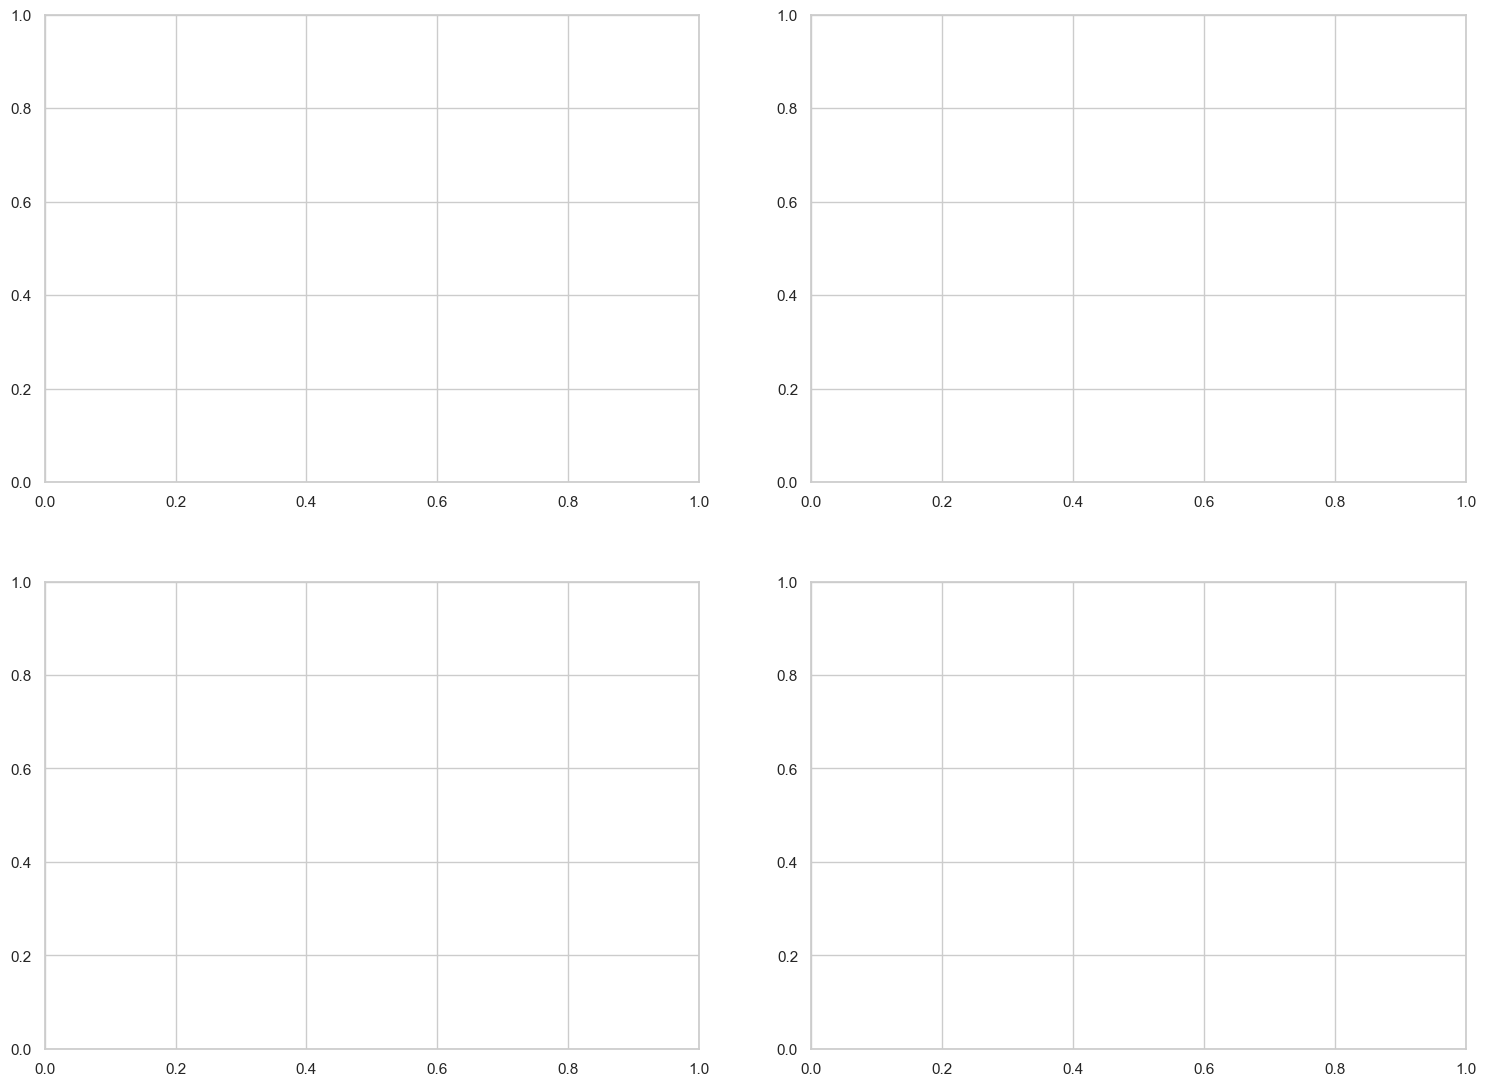

In [53]:
# 2x2 dashboard

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

plt.tight_layout(pad=4)

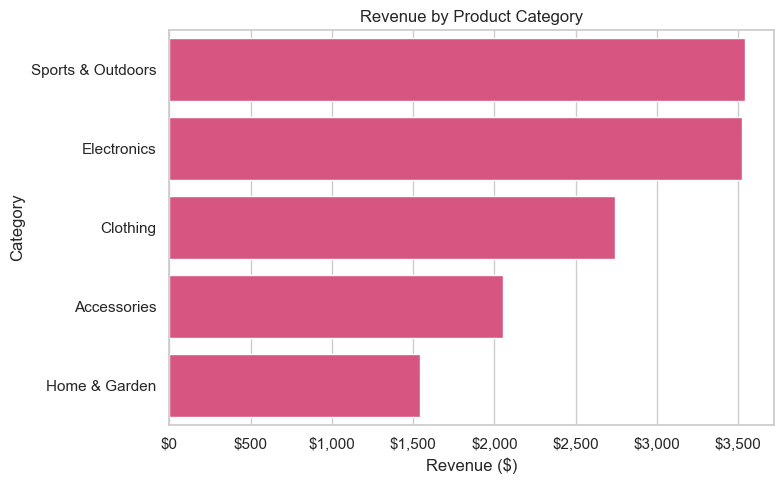

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import StrMethodFormatter

# Calculate total revenue by category
category_revenue = (
    retail_data.groupby("category")["total_amount"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

sns.barplot(
    x=category_revenue.values,
    y=category_revenue.index,
    color="#EC407A"   # Pink
)

plt.title("Revenue by Product Category")
plt.xlabel("Revenue ($)")
plt.ylabel("Category")

# Format x-axis as currency
plt.gca().xaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))

plt.tight_layout()
plt.show()

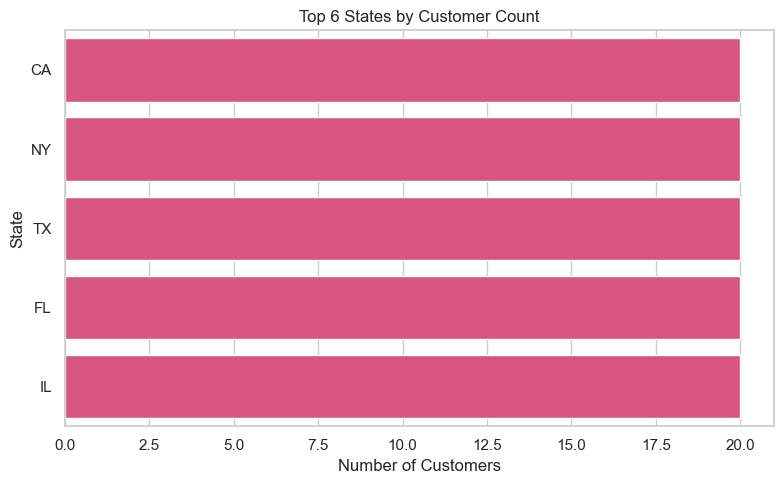

In [55]:
# Count customers by state
state_counts = (
    customers["state"]
    .value_counts()
    .head(6)
)

plt.figure(figsize=(8,5))

sns.barplot(
    x=state_counts.values,
    y=state_counts.index,
    color="#EC407A"
)

plt.title("Top 6 States by Customer Count")
plt.xlabel("Number of Customers")
plt.ylabel("State")

plt.tight_layout()
plt.show()

In [56]:
# Convert transaction_date to datetime
sales["transaction_date"] = pd.to_datetime(sales["transaction_date"])

# Create a day of the week column
sales["day_of_week"] = sales["transaction_date"].dt.day_name()

# Check the result
sales[["transaction_date", "day_of_week"]].head()

,transaction_date,day_of_week
0,2022-02-10 14:30:00,Thursday
1,2022-02-15 10:15:00,Tuesday
2,2022-02-20 16:45:00,Sunday
3,2022-02-25 11:20:00,Friday
4,2022-03-01 13:10:00,Tuesday


In [57]:
# Order the days correctly
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

average_daily_sales = (
    sales.groupby("day_of_week")["total_amount"]
    .mean()
    .reindex(day_order)
)

average_daily_sales

day_of_week
Monday        90.927500
Tuesday       74.028636
Wednesday     96.071905
Thursday     102.267619
Friday       100.940833
Saturday      61.121905
Sunday        99.551429
Name: total_amount, dtype: float64

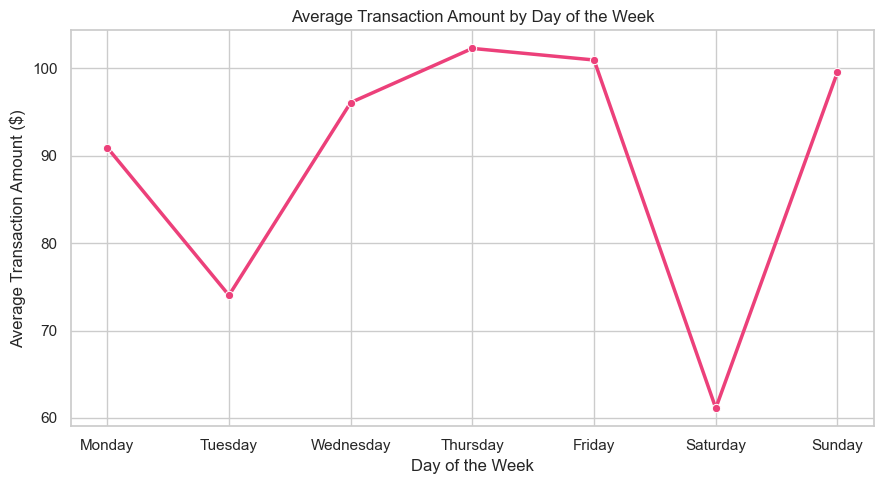

In [58]:
plt.figure(figsize=(9,5))

sns.lineplot(
    x=average_daily_sales.index,
    y=average_daily_sales.values,
    marker="o",
    linewidth=2.5,
    color="#EC407A"
)

plt.title("Average Transaction Amount by Day of the Week")
plt.xlabel("Day of the Week")
plt.ylabel("Average Transaction Amount ($)")

plt.tight_layout()
plt.show()

The chart shows that customers spend more on Thursday and Friday. Spending decreases on Saturday but goes back up on Sunday. This could mean customers make larger purchases before the weekend.

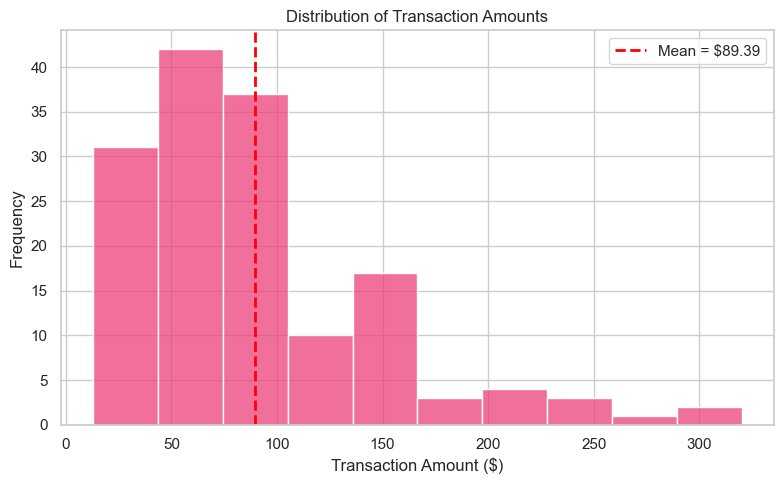

In [59]:
# Calculate the mean transaction amount
mean_transaction = sales["total_amount"].mean()

plt.figure(figsize=(8,5))

# Histogram
sns.histplot(
    sales["total_amount"],
    bins=10,
    color="#EC407A"
)

# Mean reference line
plt.axvline(
    mean_transaction,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean = ${mean_transaction:.2f}"
)

plt.title("Distribution of Transaction Amounts")
plt.xlabel("Transaction Amount ($)")
plt.ylabel("Frequency")

plt.legend()

plt.tight_layout()
plt.show()

The histogram shows that most transactions fall between $40 and $ 100. There are only a few higher-value purchases, but they increase the overall average transaction amount to $89.39.

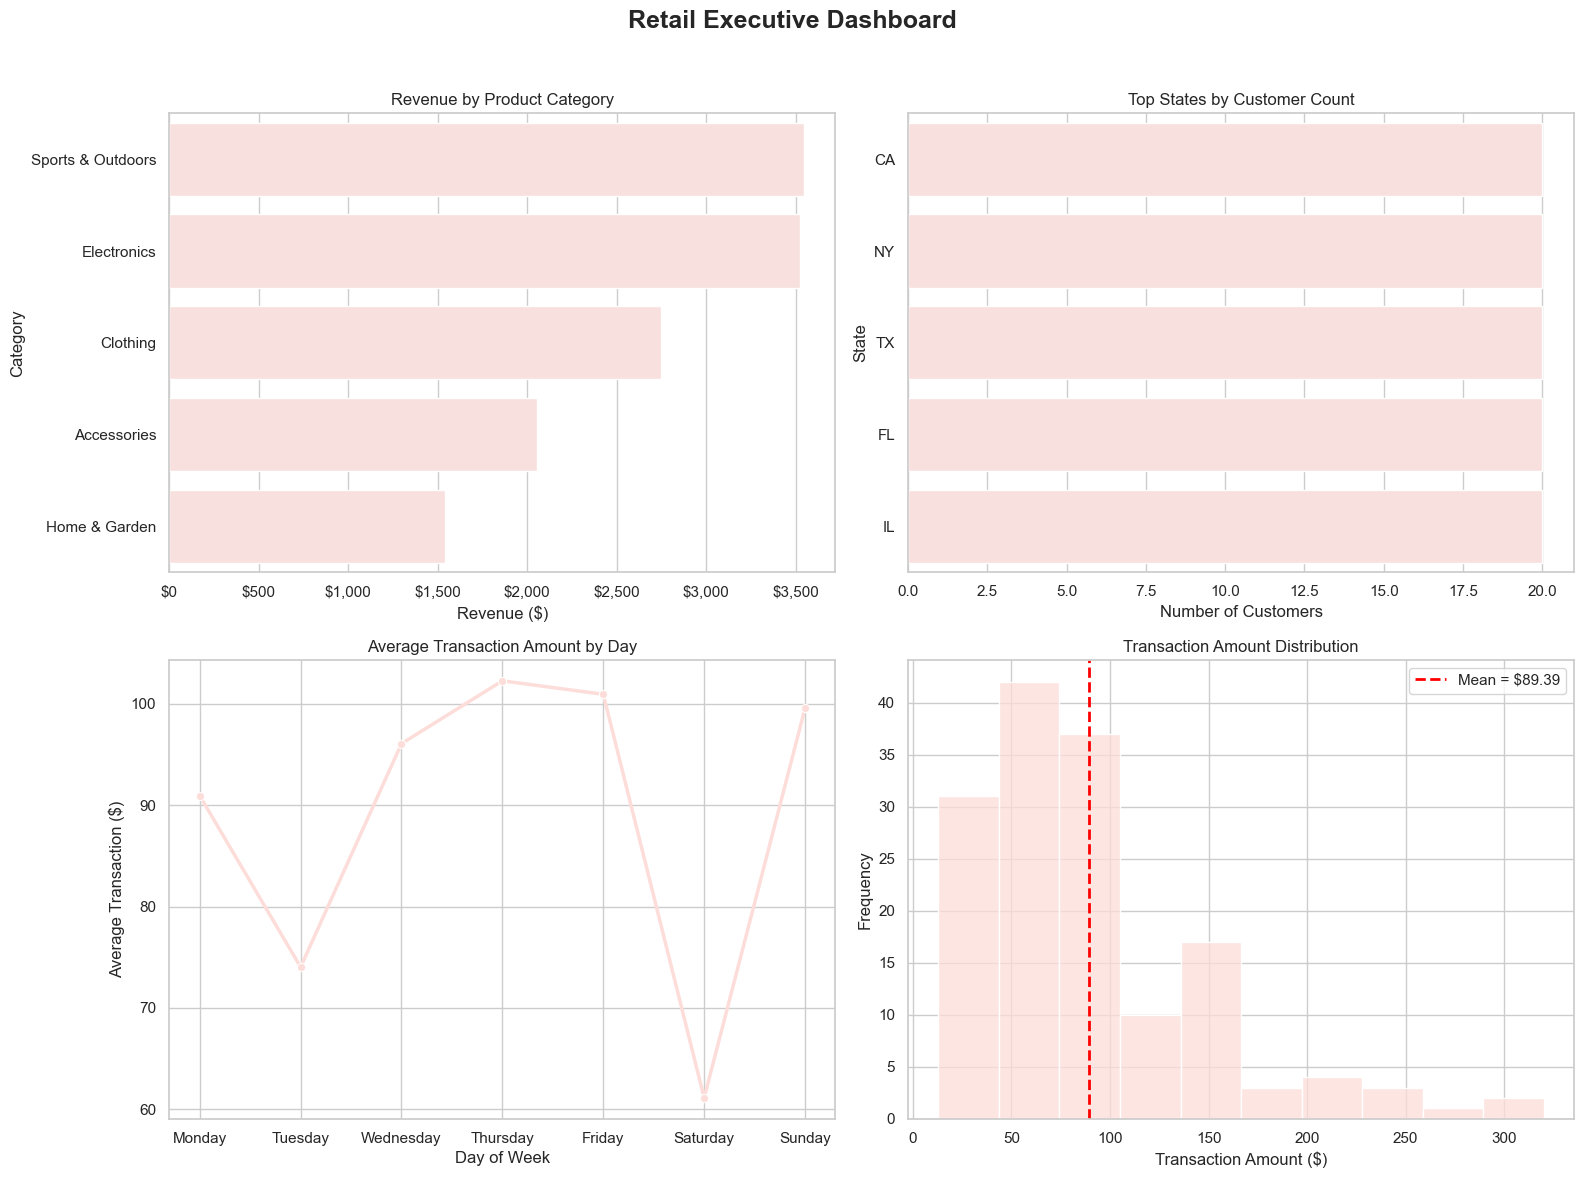

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import StrMethodFormatter

sns.set_theme(style="whitegrid", palette="RdPu")

# -------------------------------
# Prepare the data
# -------------------------------

# Chart 1
category_revenue = (
    retail_data.groupby("category")["total_amount"]
    .sum()
    .sort_values(ascending=False)
)

# Chart 2
state_counts = (
    customers["state"]
    .value_counts()
    .head(6)
)

# Chart 3
sales["transaction_date"] = pd.to_datetime(sales["transaction_date"])
sales["day_of_week"] = sales["transaction_date"].dt.day_name()

day_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

average_daily_sales = (
    sales.groupby("day_of_week")["total_amount"]
    .mean()
    .reindex(day_order)
)

# Chart 4
mean_transaction = sales["total_amount"].mean()

# -------------------------------
# Create Dashboard
# -------------------------------

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# -------------------------------
# Chart 1
# -------------------------------

sns.barplot(
    x=category_revenue.values,
    y=category_revenue.index,
    ax=axes[0,0]
)

axes[0,0].set_title("Revenue by Product Category")
axes[0,0].set_xlabel("Revenue ($)")
axes[0,0].set_ylabel("Category")
axes[0,0].xaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))

# -------------------------------
# Chart 2
# -------------------------------

sns.barplot(
    x=state_counts.values,
    y=state_counts.index,
    ax=axes[0,1]
)

axes[0,1].set_title("Top States by Customer Count")
axes[0,1].set_xlabel("Number of Customers")
axes[0,1].set_ylabel("State")

# -------------------------------
# Chart 3
# -------------------------------

sns.lineplot(
    x=average_daily_sales.index,
    y=average_daily_sales.values,
    marker="o",
    linewidth=2.5,
    ax=axes[1,0]
)

axes[1,0].set_title("Average Transaction Amount by Day")
axes[1,0].set_xlabel("Day of Week")
axes[1,0].set_ylabel("Average Transaction ($)")

# -------------------------------
# Chart 4
# -------------------------------

sns.histplot(
    sales["total_amount"],
    bins=10,
    ax=axes[1,1]
)

axes[1,1].axvline(
    mean_transaction,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean = ${mean_transaction:.2f}"
)

axes[1,1].legend()

axes[1,1].set_title("Transaction Amount Distribution")
axes[1,1].set_xlabel("Transaction Amount ($)")
axes[1,1].set_ylabel("Frequency")

# -------------------------------
# Dashboard Title
# -------------------------------

fig.suptitle(
    "Retail Executive Dashboard",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.show()

In [61]:
print(sales.columns.tolist())

['sale_id', 'customer_id', 'product_id', 'transaction_date', 'quantity', 'total_amount', 'day_of_week']


In [62]:
sales.head()

,sale_id,customer_id,product_id,transaction_date,quantity,total_amount,day_of_week
0,1,1,1,2022-02-10 14:30:00,1,79.99,Thursday
1,2,2,3,2022-02-15 10:15:00,2,39.98,Tuesday
2,3,3,5,2022-02-20 16:45:00,1,34.99,Sunday
3,4,4,2,2022-02-25 11:20:00,3,74.97,Friday
4,5,5,4,2022-03-01 13:10:00,1,89.99,Tuesday


In [63]:
# Merge customer and sales data
customer_sales = customers.merge(
    sales,
    on="customer_id",
    how="left"
)

# Create one summary row per customer
customer_summary = (
    customer_sales
    .groupby(
        ["customer_id", "age", "income"],
        as_index=False
    )
    .agg(
        total_spending=("total_amount", "sum"),
        purchase_count=("sale_id", "count")
    )
)

# Handle customers with no purchases
customer_summary["total_spending"] = (
    customer_summary["total_spending"].fillna(0)
)

customer_summary["purchase_count"] = (
    customer_summary["purchase_count"].fillna(0)
)

customer_summary.head()

,customer_id,age,income,total_spending,purchase_count
0,1,34,75000,229.98,2
1,2,28,82000,179.96,2
2,3,45,95000,154.98,2
3,4,31,68000,234.95,2
4,5,52,110000,149.98,2


In [64]:
customer_summary["age_group"] = pd.cut(
    customer_summary["age"],
    bins=[0, 29, 45, 60, float("inf")],
    labels=[
        "Under 30",
        "30-45",
        "46-60",
        "Over 60"
    ],
    include_lowest=True
)

customer_summary.head()

,customer_id,age,income,total_spending,purchase_count,age_group
0,1,34,75000,229.98,2,30-45
1,2,28,82000,179.96,2,Under 30
2,3,45,95000,154.98,2,30-45
3,4,31,68000,234.95,2,30-45
4,5,52,110000,149.98,2,46-60


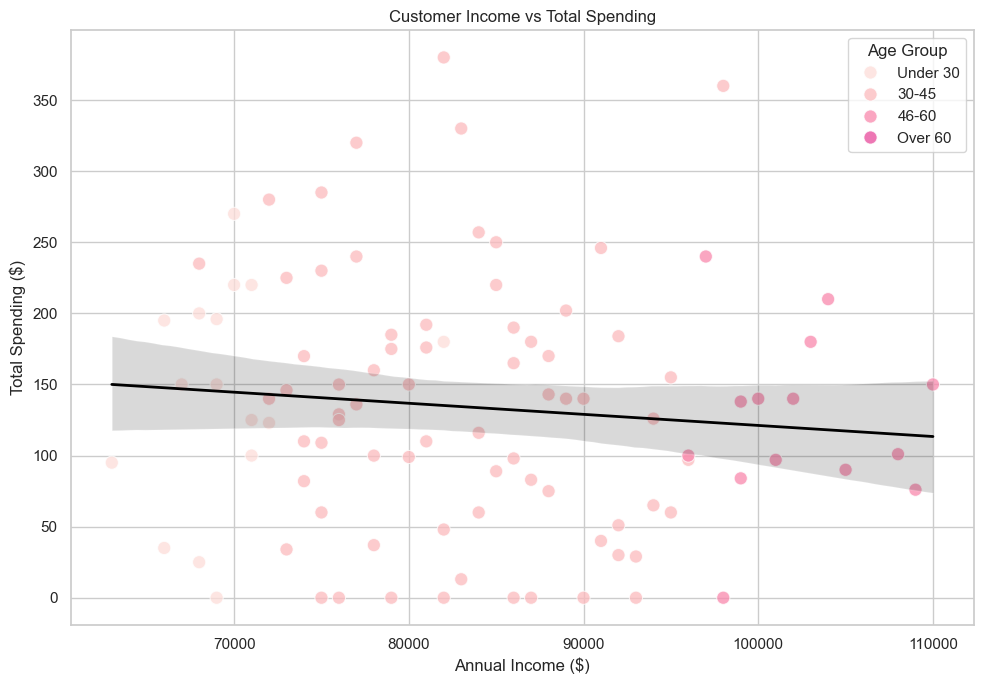

In [65]:
plt.figure(figsize=(10, 7))

# Scatter plot
sns.scatterplot(
    data=customer_summary,
    x="income",
    y="total_spending",
    hue="age_group",
    s=90,
    alpha=0.75
)

# Regression line
sns.regplot(
    data=customer_summary,
    x="income",
    y="total_spending",
    scatter=False,
    color="black",
    line_kws={"linewidth": 2}
)

plt.title("Customer Income vs Total Spending")
plt.xlabel("Annual Income ($)")
plt.ylabel("Total Spending ($)")

plt.legend(title="Age Group")

plt.tight_layout()
plt.show()

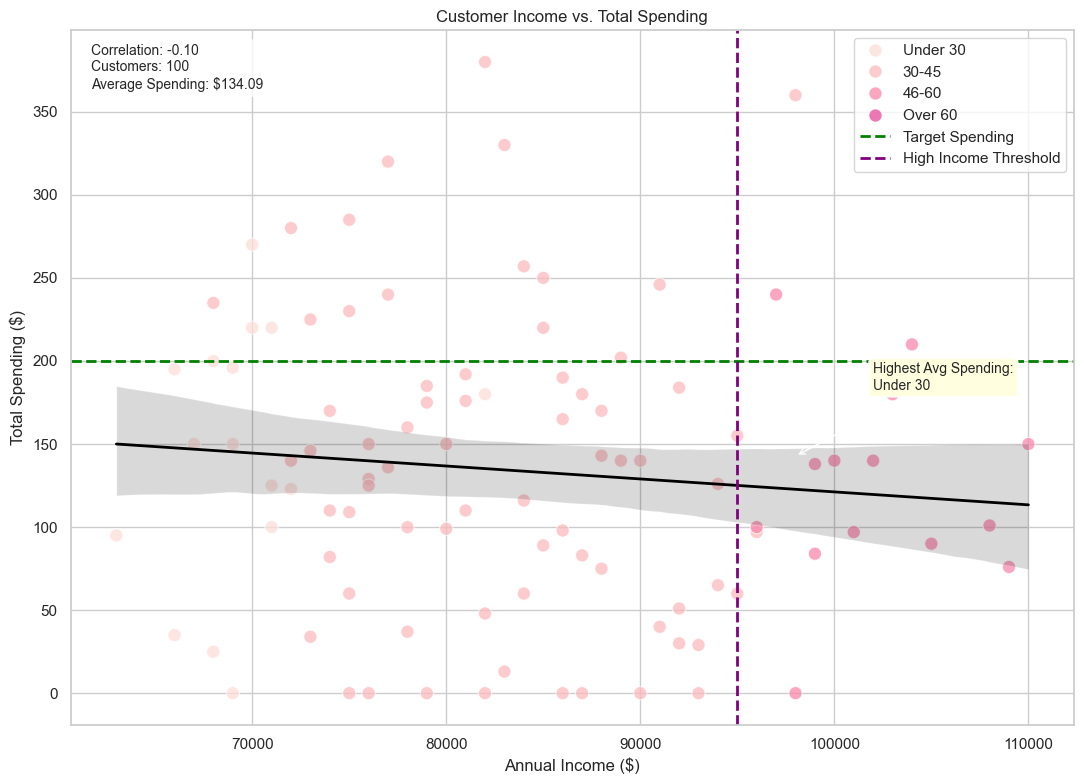

In [66]:
import numpy as np

plt.figure(figsize=(11,8))

# Scatter plot
sns.scatterplot(
    data=customer_summary,
    x="income",
    y="total_spending",
    hue="age_group",
    s=90,
    alpha=0.75
)

# Regression line
sns.regplot(
    data=customer_summary,
    x="income",
    y="total_spending",
    scatter=False,
    color="black",
    line_kws={"linewidth":2}
)

# -----------------------------
# Business reference lines
# -----------------------------
target_spending = 200
high_income = 95000

plt.axhline(
    target_spending,
    color="green",
    linestyle="--",
    linewidth=2,
    label="Target Spending"
)

plt.axvline(
    high_income,
    color="purple",
    linestyle="--",
    linewidth=2,
    label="High Income Threshold"
)

# -----------------------------
# Correlation
# -----------------------------
corr = customer_summary["income"].corr(customer_summary["total_spending"])

# -----------------------------
# Metrics box
# -----------------------------
metrics = (
    f"Correlation: {corr:.2f}\n"
    f"Customers: {len(customer_summary)}\n"
    f"Average Spending: ${customer_summary['total_spending'].mean():.2f}"
)

plt.text(
    0.02,
    0.98,
    metrics,
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)

# -----------------------------
# Best-performing age group
# -----------------------------
best_group = (
    customer_summary
    .groupby("age_group")["total_spending"]
    .mean()
    .idxmax()
)

best_value = (
    customer_summary
    .groupby("age_group")["total_spending"]
    .mean()
    .max()
)

plt.annotate(
    f"Highest Avg Spending:\n{best_group}",
    xy=(98000, best_value),
    xytext=(102000, best_value + 40),
    arrowprops=dict(arrowstyle="->"),
    fontsize=10,
    bbox=dict(boxstyle="round", facecolor="lightyellow")
)

plt.title("Customer Income vs. Total Spending")
plt.xlabel("Annual Income ($)")
plt.ylabel("Total Spending ($)")

plt.legend()

plt.tight_layout()

plt.show()